# Starting with parametric methods in pandas and scipy

O coeficiente de correlação de Pearson é uma medida estatística que quantifica a força e a direção da relação linear entre duas variáveis quantitativas.
Definição
O coeficiente de correlação de Pearson, frequentemente representado pela letra "r", é uma ferramenta estatística que mede a intensidade e a direção da relação linear entre duas variáveis. Ele varia entre -1 e 1, onde:

r = 1: Indica uma correlação linear perfeita positiva (quando uma variável aumenta, a outra também aumenta de maneira consistente).
r = -1: Indica uma correlação linear perfeita negativa (quando uma variável aumenta, a outra diminui de maneira consistente).
r = 0: Indica que não há correlação linear entre as variáveis 
datageeks.com.br
datageeks.com.br
+1
.
Cálculo
O coeficiente de correlação de Pearson é calculado usando a seguinte fórmula:


$$
\frac{\mathrm{cov}(X, Y)}{\sigma_X \cdot \sigma_Y}
$$


onde:

- $\mathrm{cov}(X, Y)$ é a covariância entre as variáveis $X$ e $Y$  
- $\sigma_X$ e $\sigma_Y$ são os desvios padrão das variáveis $X$ e $Y$, respectivamente



In [1]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

import scipy
from scipy.stats import pearsonr

In [2]:
%matplotlib inline
rcParams['figure.figsize']= 8,6
sns.set_style('whitegrid')

## The Pearson Correlation

[Descrição dos Campos cars](Cars_DescriçãoCampos.md)

In [3]:
address = r'.\cars.csv'
cars = pd.read_csv(address)
cars.columns = ['car_names','mpg','cyl','disp','hp','drat','wt','qsec','vs','am','gear','carb']
# Não aparece coluna de índice
cars.index = cars.car_names
cars.head(15)

,car_names,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
car_names,,,,,,,,,,,,
Mazda RX4,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


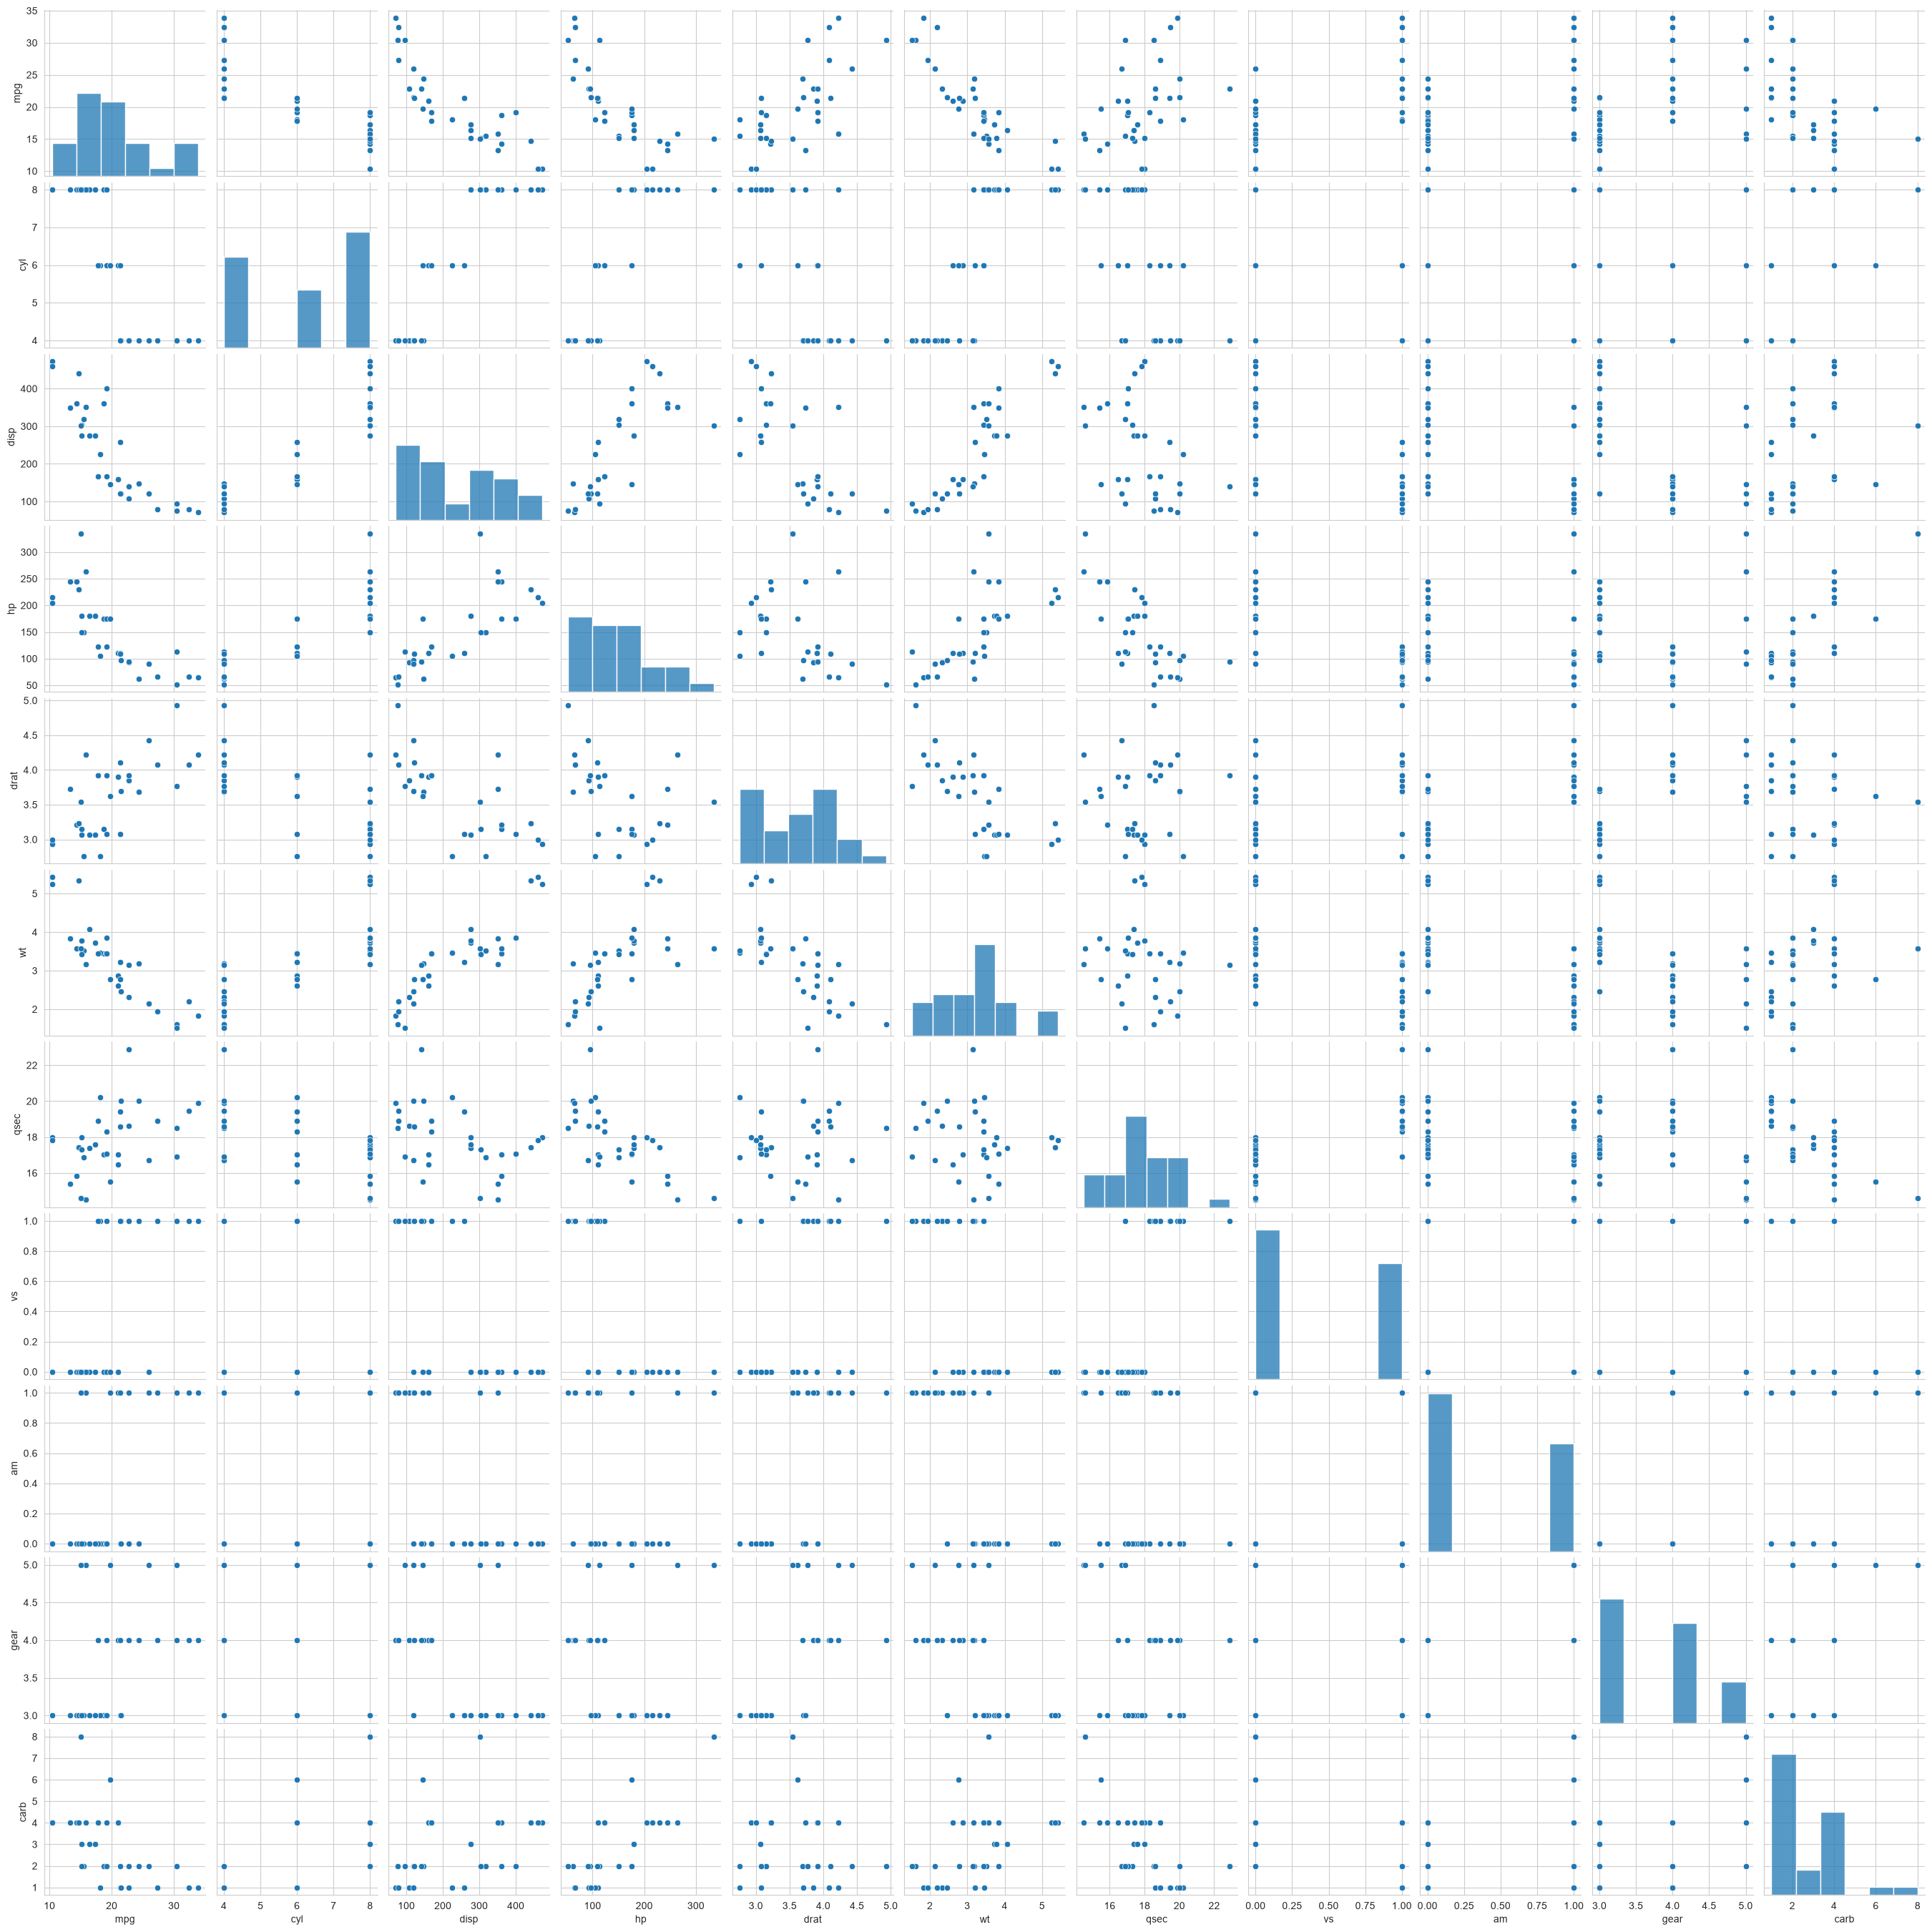

In [4]:
sns.pairplot(cars)

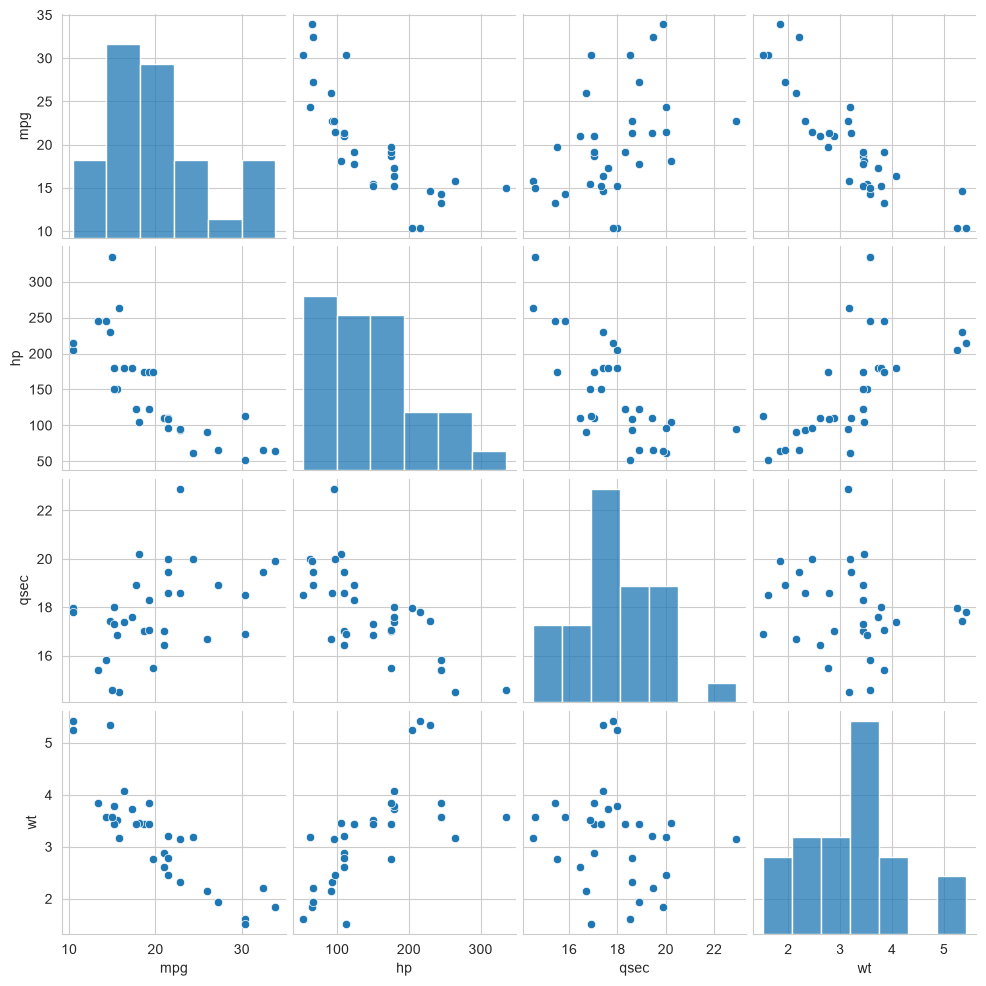

In [5]:
x = cars[['mpg','hp','qsec', 'wt']]
sns.pairplot(x)

## Using scipy to calculate the Pearson correlation coefficient

In [6]:
mpg = cars['mpg']
hp = cars['hp']
qsec = cars['qsec']
wt = cars['wt']

pearsonr_coefficient, p_value = pearsonr(mpg, hp)
print('PearsonR Correlation Coefficient %0.3f' % (pearsonr_coefficient))

PearsonR Correlation Coefficient -0.776


In [7]:
pearsonr_coefficient, p_value = pearsonr(mpg, qsec)
print('PearsonR Correlation Coefficient %0.3f' % (pearsonr_coefficient))

PearsonR Correlation Coefficient 0.419


In [8]:
pearsonr_coefficient, p_value = pearsonr(mpg, wt)
print('PearsonR Correlation Coefficient %0.3f' % (pearsonr_coefficient))

PearsonR Correlation Coefficient -0.868


## Using Pandas to visualize the Pearson correlation coefficient

In [9]:
corr = x.corr()
corr

,mpg,hp,qsec,wt
mpg,1.000000,-0.776168,0.418684,-0.867659
hp,-0.776168,1.000000,-0.708223,0.658748
qsec,0.418684,-0.708223,1.000000,-0.174716
wt,-0.867659,0.658748,-0.174716,1.000000


## Using Seaborn to visualize the Pearson correlation coefficient

In [10]:
# Armazena os títulos das colunas
corr.columns.values

<StringArray>
['mpg', 'hp', 'qsec', 'wt']
Length: 4, dtype: str

<Axes: >

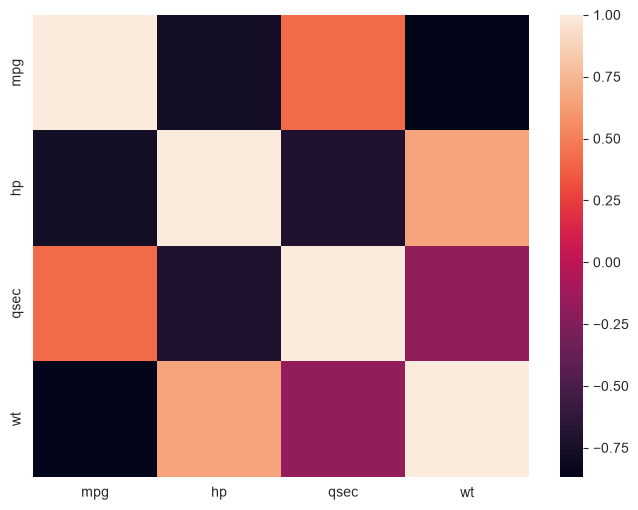

In [11]:
# Mapa de calor
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values)